In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

[1 1 1 0 1 1 1 0 1 1 0 0 0 0 1 0 0 1 0 1 1 0 1 1 1 1 0 1 0 1 1 1 1 1 0 1 1
 1 0 0 1 1 1 1 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 1 0 1 0 0 0 1 1 1 1 1 1 0
 0 0 0 1 1 1 0 0 0 0 0 0 0 1 1 0 1 0 0 0 1 1 0 1 1 0]


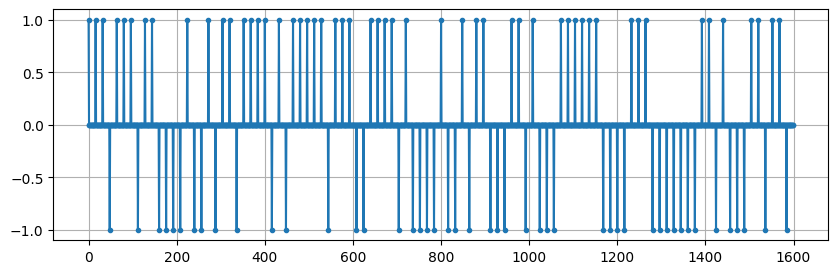

In [8]:
num_symbols = 100
sps = 16

bits = np.random.randint(0, 2, num_symbols) # Our data to be transmitted, 1's and 0's
print(bits)
x = np.array([])
for bit in bits:
    pulse = np.zeros(sps)
    pulse[0] = bit*2-1 # set the first value to either a 1 or -1
    x = np.concatenate((x, pulse)) # add the 8 samples to the signal
plt.figure(figsize=(10, 3))
plt.plot(x, '.-')
plt.grid(True)
plt.show()

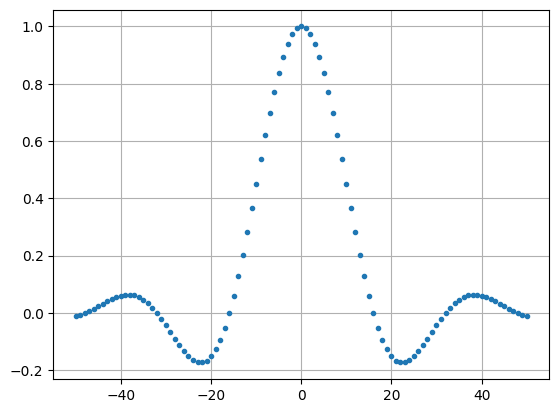

In [9]:
num_taps = 101
beta = 0.34
Ts = sps # Assume sample rate is 1 Hz, so sample period is 1, so *symbol* period is 8
t = np.arange(num_taps) - (num_taps-1)//2
h = np.sinc(t/Ts) * np.cos(np.pi*beta*t/Ts) / (1 - (2*beta*t/Ts)**2)


plt.figure(1)
plt.plot(t, h, '.')
plt.grid(True)
plt.show()

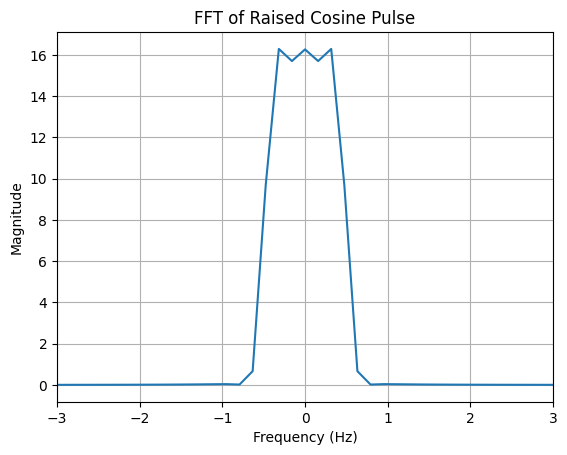

In [10]:
H = np.fft.fftshift(np.fft.fft(h))
freq = np.fft.fftshift(np.fft.fftfreq(num_taps, d=1/Ts)) # d is the sample spacing

plt.figure(2)
plt.plot(freq, abs(H))
plt.grid(True)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('FFT of Raised Cosine Pulse')
plt.xlim(-3, 3)
plt.show()

In [11]:
x_shaped = np.convolve(x, h, mode = 'full')

In [12]:
# Sample the convolved signal
sampled_symbols = x_shaped[num_taps // 2 : : sps][:num_symbols]

# Print the sampled symbols
print("Sampled Symbols:", np.round(sampled_symbols > 0))

Sampled Symbols: [1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 0. 1. 1.
 1. 1. 0. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0.
 0. 0. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1.
 1. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1.
 0. 1. 1. 0.]


[1 1 1 0 1 1 1 0 1 1 0 0 0 0 1 0 0 1 0 1 1 0 1 1 1 1 0 1 0 1 1 1 1 1 0 1 1
 1 0 0 1 1 1 1 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 1 0 1 0 0 0 1 1 1 1 1 1 0
 0 0 0 1 1 1 0 0 0 0 0 0 0 1 1 0 1 0 0 0 1 1 0 1 1 0]


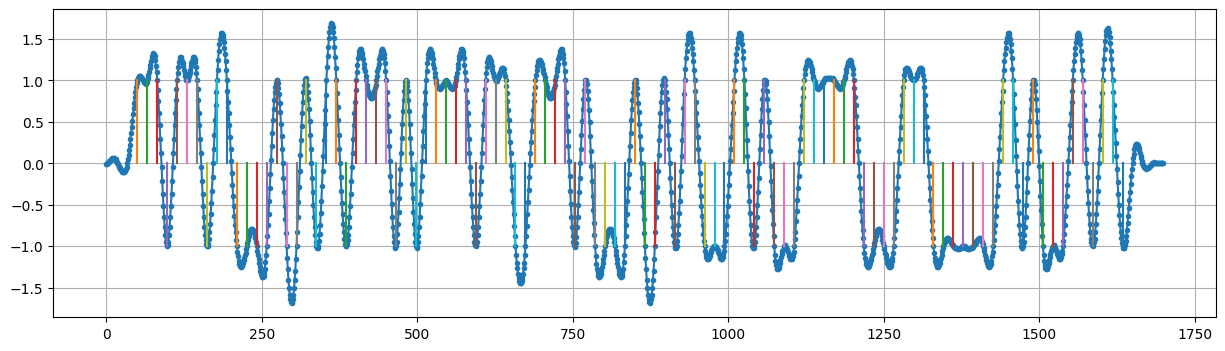

In [13]:

print(bits)
plt.figure(figsize=(15, 4))
plt.plot(x_shaped, '.-')
for i in range(num_symbols):
    plt.plot([i*sps+num_taps//2,i*sps+num_taps//2], [0, x_shaped[i*sps+num_taps//2]])
plt.grid(True)
plt.show()

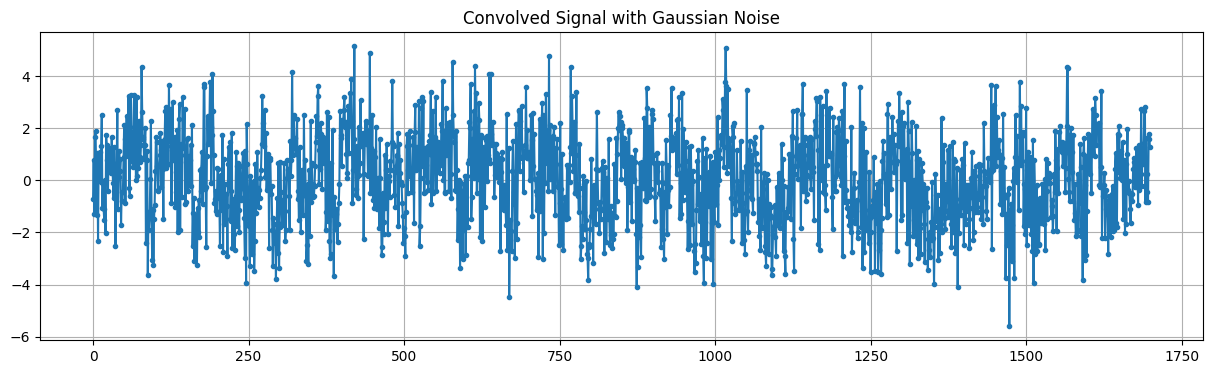

In [14]:
# Add Gaussian noise
noise_power = 2 # You can adjust the noise power as needed
noise = np.random.normal(0, np.sqrt(noise_power), len(x_shaped))
x_noisy = x_shaped + noise

# Plot the noisy signal
plt.figure(figsize=(15, 4))
plt.plot(x_noisy, '.-')
plt.grid(True)
plt.title('Convolved Signal with Gaussian Noise')
plt.show()

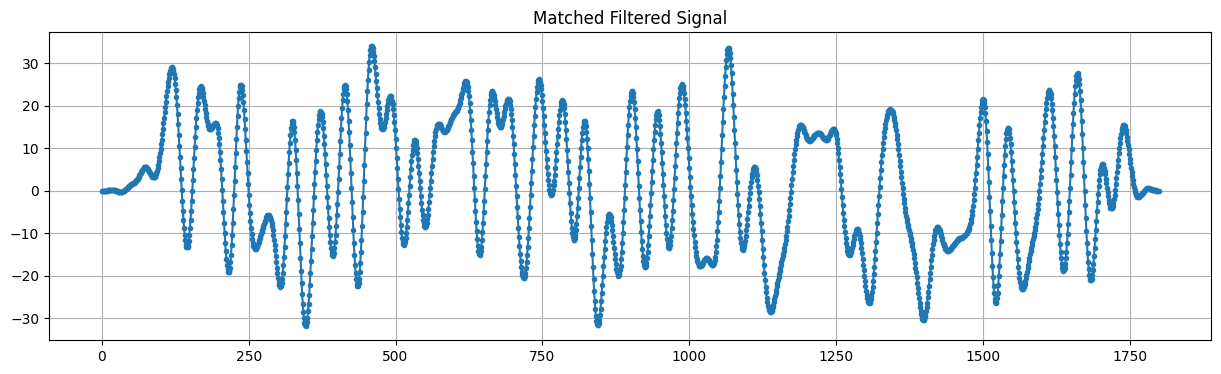

In [15]:
# Perform matched filtering by convolving the noisy signal with the raised cosine filter
x_matched_filtered = np.convolve(x_noisy, h, mode='full')
# x_matched_filtered = x_noisy
# Plot the matched filtered signal (optional, but good for visualization)
plt.figure(figsize=(15, 4))
plt.plot(x_matched_filtered, '.-')
plt.grid(True)
plt.title('Matched Filtered Signal')
plt.show()

In [16]:
def compute_snr(signal, noise):
    signal_power = np.mean(signal**2)
    noise_power = np.mean(noise**2)
    return 10 * np.log10(signal_power / noise_power)

print(compute_snr(x_noisy, noise))

print(compute_snr(x_matched_filtered, noise))

1.5824915639958457
20.578462120977903
